In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np 
import geopandas as gpd

file_path = "C:\\Users\\Andrea\\Downloads\\nat_and_corruption.csv\\nat_and_corruption.csv"
path_geodata = "C:\\Users\\Andrea\\Downloads\\nat_and_corruption.csv\\world-administrative-boundaries\\world-administrative-boundaries.shp"

# Dataframe creation
df = pd.read_csv(file_path)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18628 entries, 0 to 18627
Data columns (total 30 columns):
 #   Column                                                      Non-Null Count  Dtype  
---  ------                                                      --------------  -----  
 0   iso3c                                                       18628 non-null  object 
 1   year                                                        18628 non-null  int64  
 2   country_name                                                18628 non-null  object 
 3   v2exl_legitideol                                            18293 non-null  float64
 4   v2exl_legitideolcr_0                                        18506 non-null  float64
 5   v2exl_legitideolcr_1                                        18506 non-null  float64
 6   v2exl_legitideolcr_2                                        18506 non-null  float64
 7   v2exl_legitideolcr_3                                        18506 non-null  float64
 

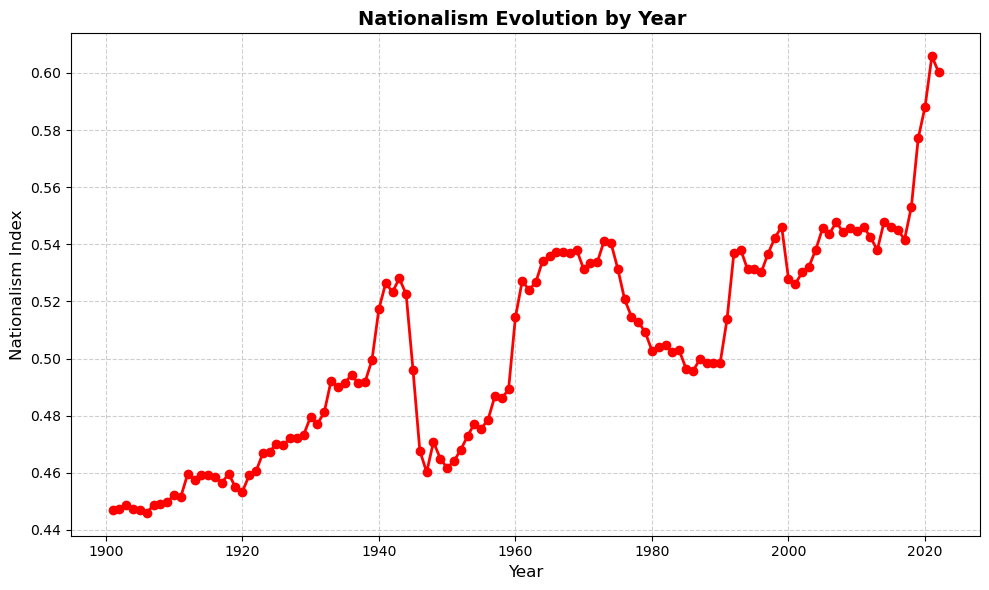

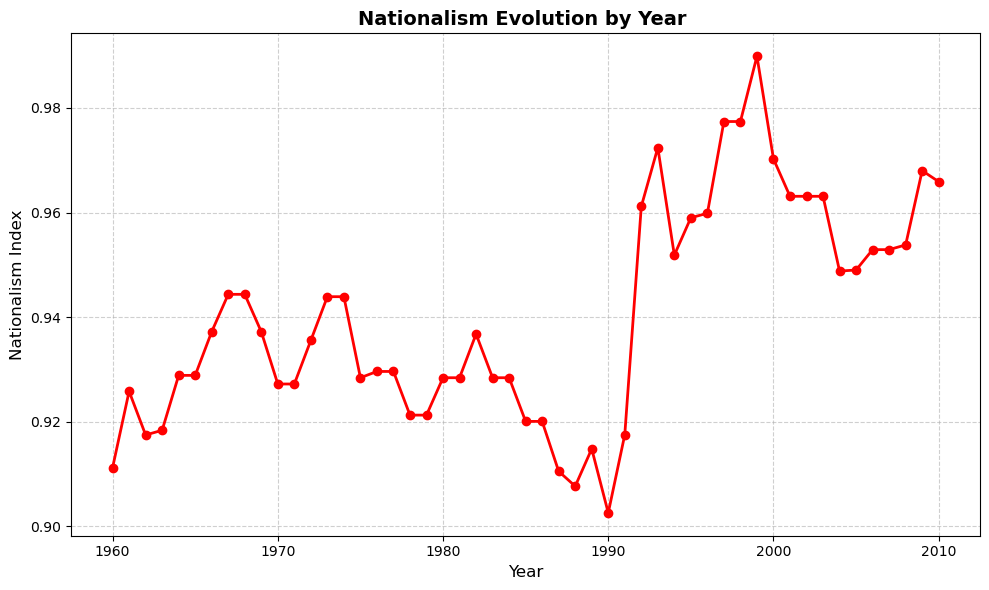

In [2]:
# Nationalism Evolution 

# Dataframe information
df_nationalism_y = df.groupby('year')[('ideology_is_nationalist_percent_of_experts')].mean()

# Create graph
plt.figure(figsize=(10, 6))
df_nationalism_y.plot(kind='line', color='red', marker='o', linestyle='-', linewidth=2)

# Title and labels 
plt.title('Nationalism Evolution by Year ', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Nationalism Index', fontsize=12)

# Show graph
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Nationalism Evolution (2000 - 2022)

# Dataframe information
df_filtered = df[(df['year'] >= 1960) & (df['year'] <= 2010)]
df_nationalism = (
    df_filtered.groupby('year')['ideology_is_nationalist_percent_of_experts']
    .nlargest(20)
    .groupby(level=0)
    .mean()
)

# Create graph
plt.figure(figsize=(10, 6))
df_nationalism.plot(kind='line', color='red', marker='o', linestyle='-', linewidth=2)

# Title and labels 
plt.title('Nationalism Evolution by Year ', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Nationalism Index', fontsize=12)

# Show graph
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

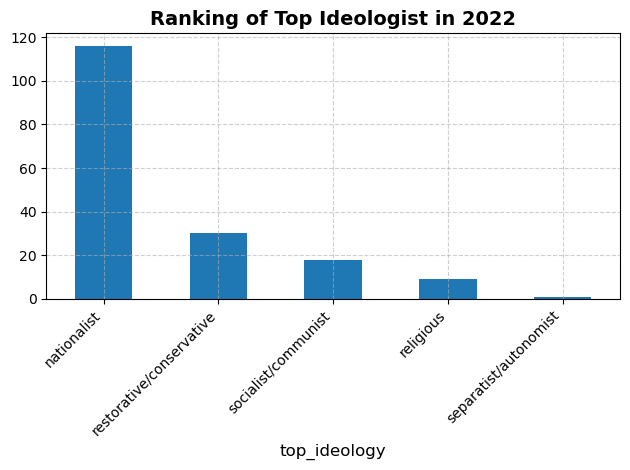

In [3]:
#Dataframe information
df_year= df[df['year'] == 2022]

#Title and labels
plt.title('Ranking of Top Ideologist in 2022', fontsize=14, fontweight='bold')
plt.xlabel('Country', fontsize=12)

df_year['top_ideology'].value_counts().head(10).plot.bar()

plt.xticks(rotation=45, ha='right') 
plt.grid(True, linestyle='--', alpha=0.6)

#Show graphic
plt.tight_layout()
plt.show()

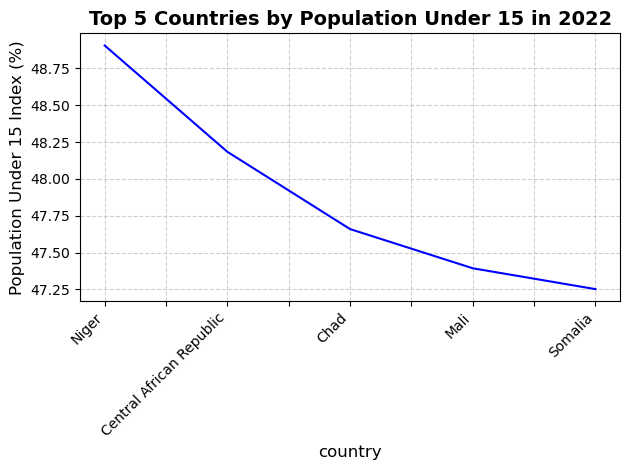

In [4]:
#Top 5 Countries by Population Under 15 in 2022

#Dataframe information
df_year= df[df['year'] == 2022]

#Title and labels
plt.title('Top 5 Countries by Population Under 15 in 2022', fontsize=14, fontweight='bold')
plt.xlabel('Country', fontsize=12)
plt.ylabel('Population Under 15 Index (%)', fontsize=12)

(df_year.groupby('country')['wdi_pop_under_15']
              .mean(5)
              .sort_values(ascending=False)
              .head()
              .plot.line(color='blue'))



plt.xticks(rotation=45, ha='right') 
plt.grid(True, linestyle='--', alpha=0.6)

#Show graphic
plt.tight_layout()
plt.show()

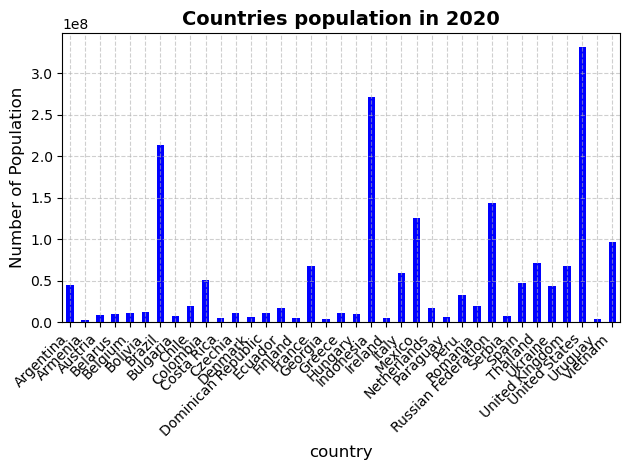

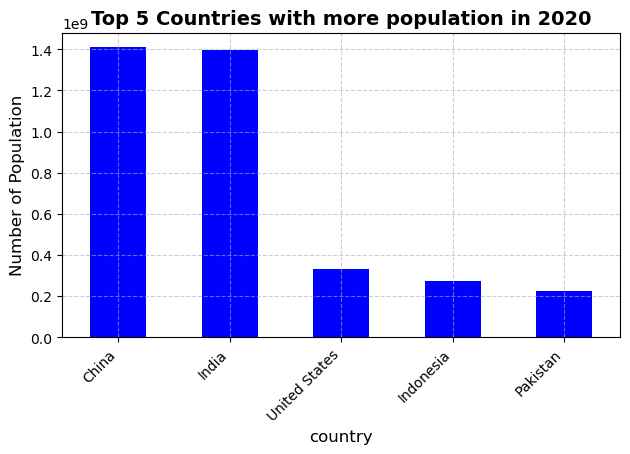

In [5]:
#Countries population in 2022

#Dataframe information
df_year= df[df['year'] == 2020].dropna()

#Title and labels
plt.title('Countries population in 2020', fontsize=14, fontweight='bold')
plt.xlabel('Country', fontsize=12)
plt.ylabel('Number of Population', fontsize=12)

((df_year.groupby('country')['wdi_population']
              .mean(5)
              .plot.bar(color='blue')))

plt.xticks(rotation=45, ha='right') 
plt.grid(True, linestyle='--', alpha=0.6)

#Show graphic
plt.tight_layout()
plt.show()


#Top 5 Countries with more population in 2020

#Dataframe information
df_year= df[df['year'] == 2020]

#Title and labels
plt.title('Top 5 Countries with more population in 2020', fontsize=14, fontweight='bold')
plt.xlabel('Country', fontsize=12)
plt.ylabel('Number of Population', fontsize=12)

((df_year.groupby('country')['wdi_population']
              .mean(5)
              .sort_values(ascending=False)
              .head(5)
              .plot.bar(color='blue')))

plt.xticks(rotation=45, ha='right') 
plt.grid(True, linestyle='--', alpha=0.6)

#Show graphic
plt.tight_layout()
plt.show()

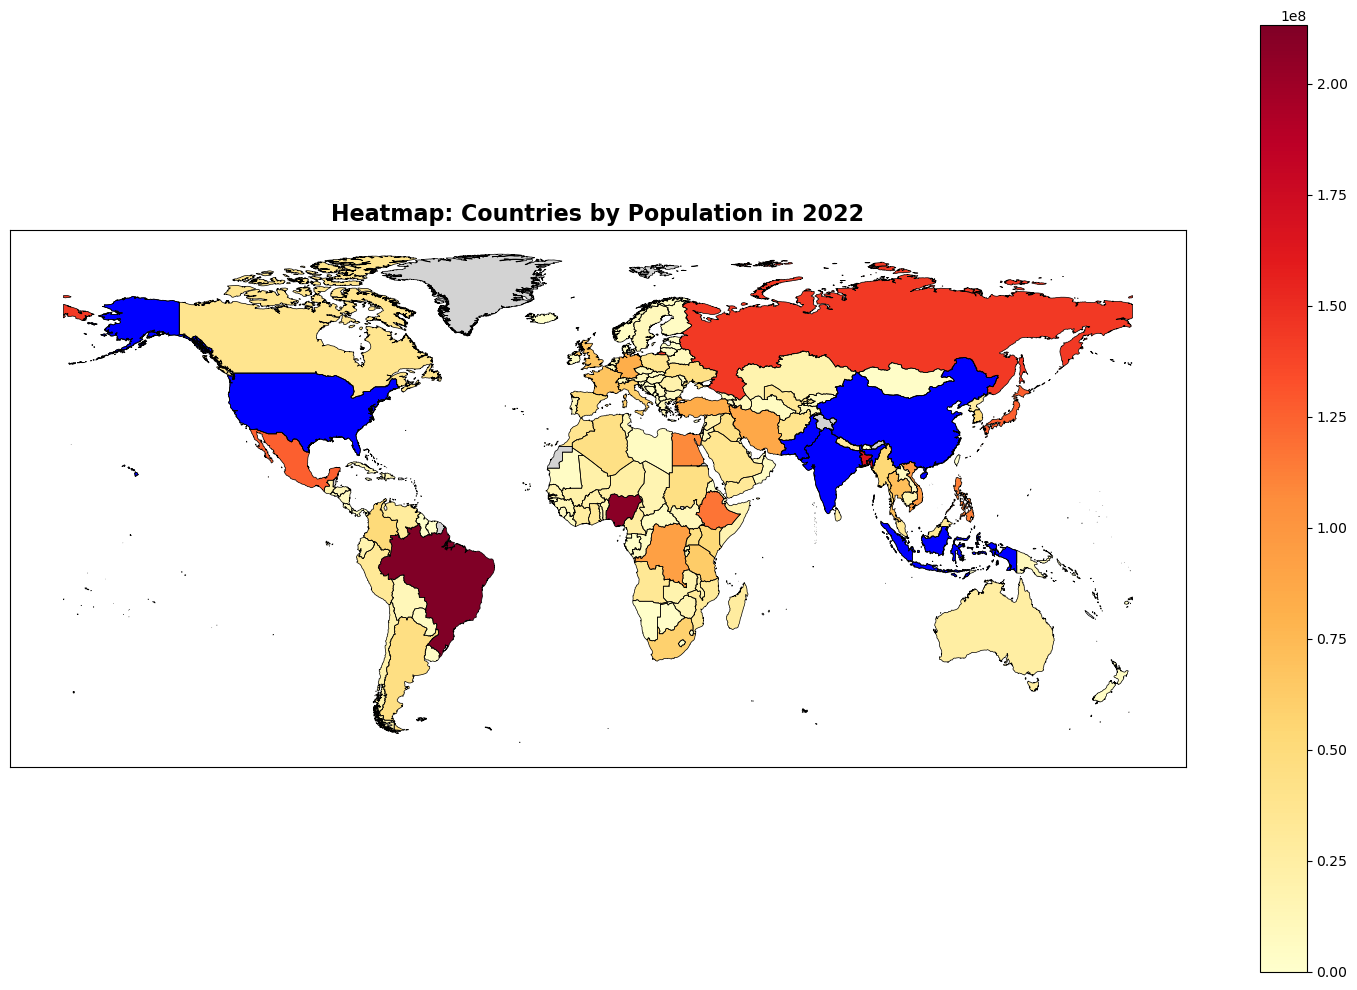

In [6]:
#Top 5 Countries with more population in 2022

# Dataframe information
df_year = df[df['year'] == 2020]

# Counties population
population_data = (df_year.groupby('iso3c')['wdi_population']).sum().reset_index()

# Upload geodata shapefile
world = gpd.read_file(path_geodata)

# Marge population data with shapefile 
world = world.merge(population_data, left_on='iso3', right_on='iso3c', how='left')

# Top 5 Countries with more population in 2020 
top_5_countries = population_data.nlargest(5, 'wdi_population')['iso3c'].tolist()

# Column with Top 5 Countries with more population in 2022 data
world['is_top_5'] = world['iso3c'].apply(lambda x: x in top_5_countries)

# Map and graph creation
fig, ax = plt.subplots(figsize=(15, 10))

# Country boundaries 
world.boundary.plot(color='black', linewidth=0.5, ax=ax)

# Mapa draw
world[~world['is_top_5']].plot(
    column='wdi_population',
    cmap='YlOrRd',
    legend=True,
    missing_kwds={"color": "lightgrey", "label": "No data"},
    ax=ax
)

# Top 5 Countries with more population in 2002 Mapa draw
world[world['is_top_5']].plot(
    color='blue',
    ax=ax,
    edgecolor='black',
    linewidth=0.5
)

# Title and configurations
plt.title('Heatmap: Countries by Population in 2022', fontsize=16, fontweight='bold')
plt.xlabel('')
plt.ylabel('')
plt.xticks([])
plt.yticks([])
plt.tight_layout()

# Show Mapa
plt.show()

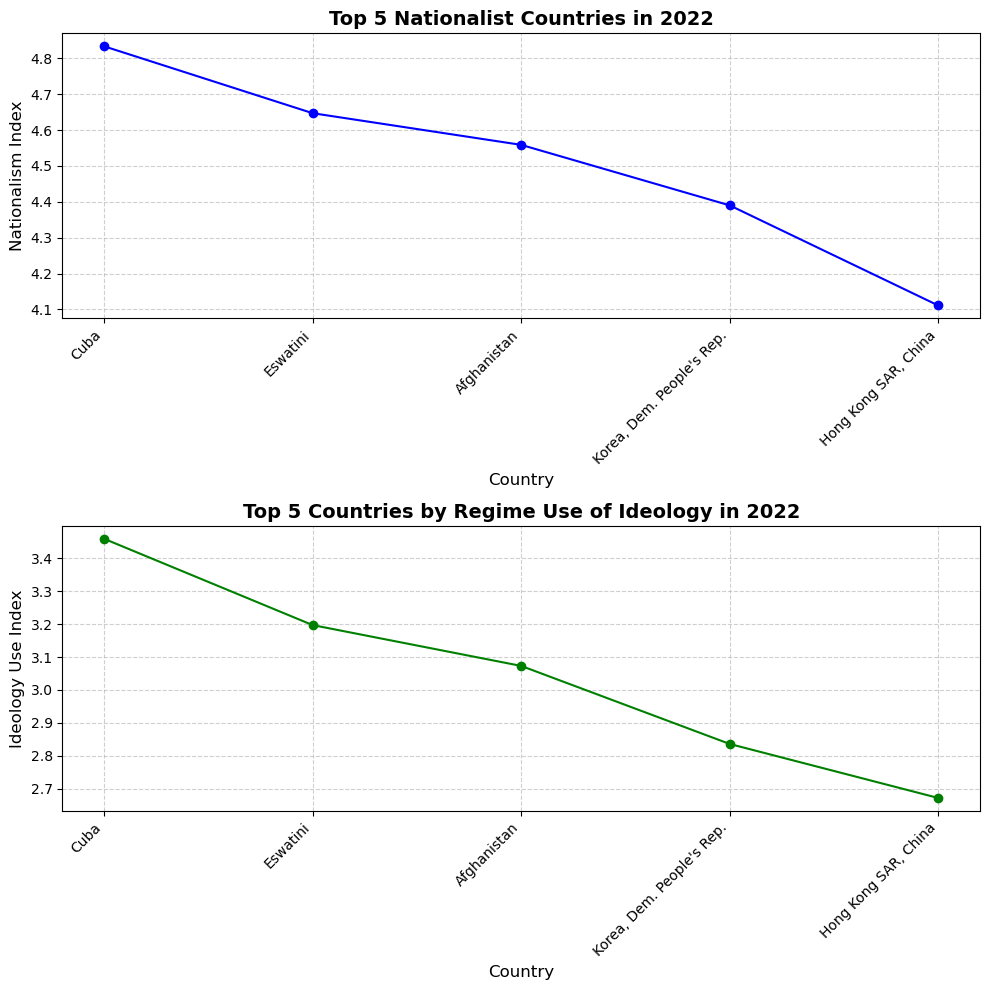

In [7]:
#Top 5 Countries by Regime Use of Ideology in 2022 and Top 5 Nationalist Countries in 2022

#Dataframe information
df_year = df[df['year'] == 2022]

#Axis creation
fig, axarr = plt.subplots(2, 1, figsize=(10, 10))

# Graphic 1: Top 5 Nationalist Countries in 2022
df_nationalism = (df_year.groupby('country')['nationalism']
                  .mean()
                  .sort_values(ascending=False)
                  .head())
df_nationalism.plot(kind='line', color='blue', marker='o', ax=axarr[0])
axarr[0].set_title('Top 5 Nationalist Countries in 2022', fontsize=14, fontweight='bold')
axarr[0].set_xlabel('Country', fontsize=12)
axarr[0].set_ylabel('Nationalism Index', fontsize=12)
axarr[0].grid(True, linestyle='--', alpha=0.6)

# Graphic 1: Top 5 Countries by Regime Use of Ideology in 2022
df_ideology = (df_year.groupby('country')['regime_use_of_ideology_measure']
               .mean()
               .sort_values(ascending=False)
               .head())
df_ideology.plot(kind='line', color='green', marker='o', ax=axarr[1])
axarr[1].set_title('Top 5 Countries by Regime Use of Ideology in 2022', fontsize=14, fontweight='bold')
axarr[1].set_xlabel('Country', fontsize=12)
axarr[1].set_ylabel('Ideology Use Index', fontsize=12)
axarr[1].grid(True, linestyle='--', alpha=0.6)

# Mejorar visualización
for ax in axarr:
    ax.set_xticks(range(len(df_nationalism.index)))
    ax.set_xticklabels(df_nationalism.index, rotation=45, ha='right')

# Ajustar el espacio entre los gráficos
plt.tight_layout()
plt.show()


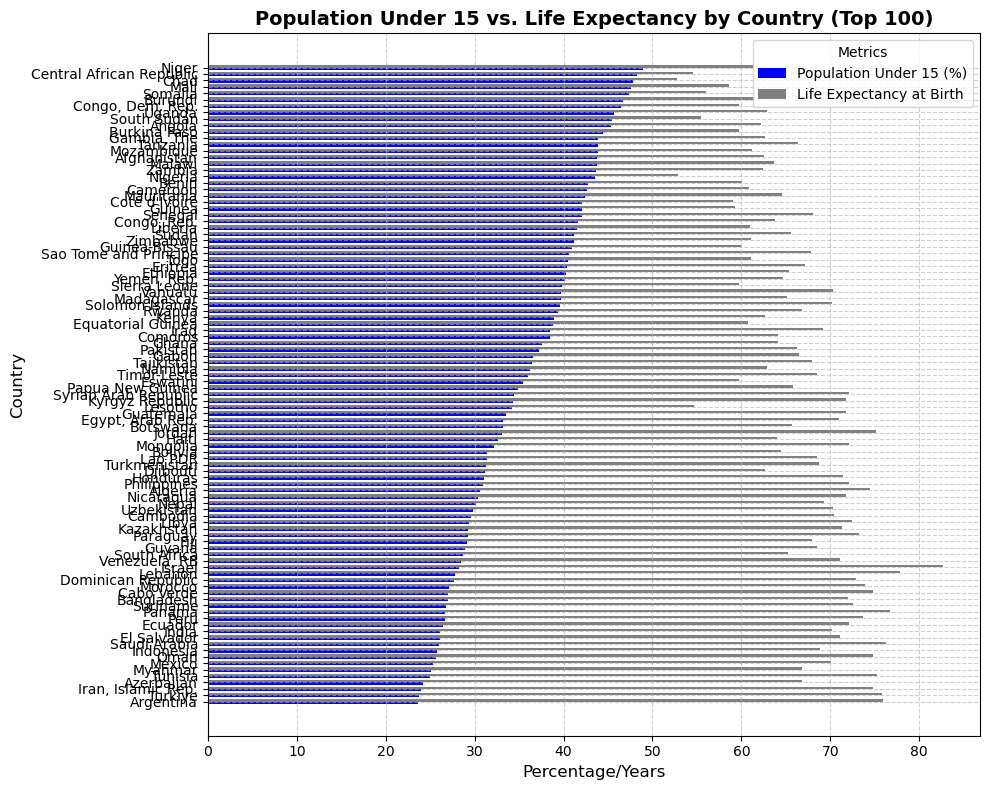

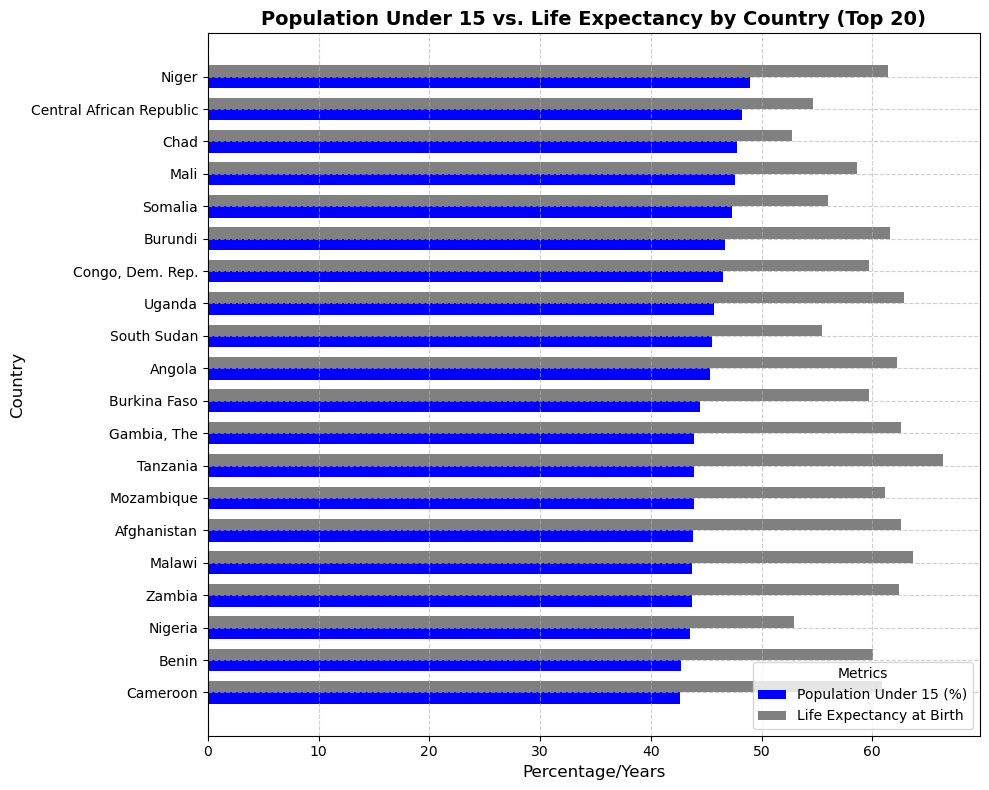

In [8]:
#Population Under 15 vs. Life Expectancy by Country (Top 100)

# Dataframe information
df_year = df[df['year'] == 2020]

df_corruption = (df_year[['country', 'wdi_pop_under_15', 'wdi_life_expectancy_at_birth']]
                 .groupby('country')
                 .mean()
                 .dropna())

df_top_countries = df_corruption.nlargest(100, 'wdi_pop_under_15').sort_values(by='wdi_pop_under_15', ascending=True)

# Crate horizontal group
plt.figure(figsize=(10, 8))
bar_width = 0.35
index = range(len(df_top_countries))

plt.barh(index,
         df_top_countries['wdi_pop_under_15'],
         height=bar_width,
         color='blue',
         label='Population Under 15 (%)')

plt.barh([i + bar_width for i in index],
         df_top_countries['wdi_life_expectancy_at_birth'],
         height=bar_width,
         color='grey',
         label='Life Expectancy at Birth')

# Graphic configuration
plt.title('Population Under 15 vs. Life Expectancy by Country (Top 100)', fontsize=14, fontweight='bold')
plt.xlabel('Percentage/Years', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.yticks([i + bar_width / 2 for i in index], df_top_countries.index)
plt.legend(title='Metrics', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)

# Show graph
plt.tight_layout()
plt.show()


#Population Under 15 vs. Life Expectancy by Country (Top 20)

# Dataframe information
df_year = df[df['year'] == 2020]

df_corruption = (df_year[['country', 'wdi_pop_under_15', 'wdi_life_expectancy_at_birth']]
                 .groupby('country')
                 .mean()
                 .dropna())

df_top_countries = df_corruption.nlargest(20, 'wdi_pop_under_15').sort_values(by='wdi_pop_under_15', ascending=True)

# Crate horizontal group
plt.figure(figsize=(10, 8))
bar_width = 0.35  
index = range(len(df_top_countries)) 

plt.barh(index, 
         df_top_countries['wdi_pop_under_15'], 
         height=bar_width, 
         color='blue', 
         label='Population Under 15 (%)')

plt.barh([i + bar_width for i in index], 
         df_top_countries['wdi_life_expectancy_at_birth'], 
         height=bar_width, 
         color='grey', 
         label='Life Expectancy at Birth')

# Graphic configuration
plt.title('Population Under 15 vs. Life Expectancy by Country (Top 20)', fontsize=14, fontweight='bold')
plt.xlabel('Percentage/Years', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.yticks([i + bar_width / 2 for i in index], df_top_countries.index)
plt.legend(title='Metrics', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)

# Show graph
plt.tight_layout()
plt.show()

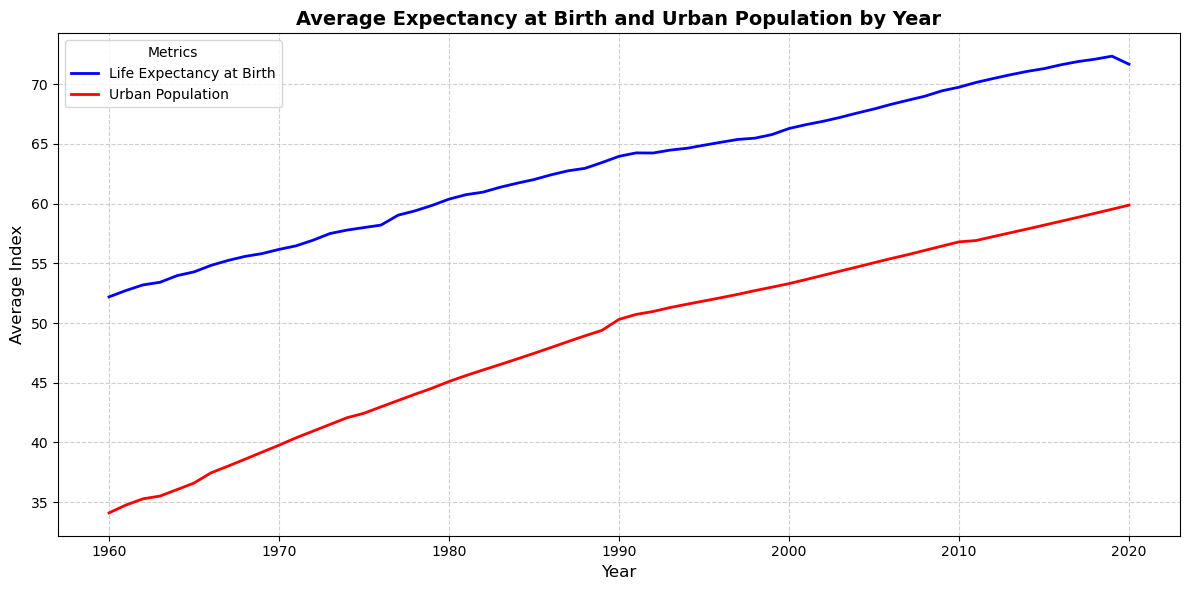

In [9]:
# Average Expectancy at Birth and Urban Population by Year

# Dataframe Information
df_exbirth_population = df[['year', 'wdi_life_expectancy_at_birth', 'wdi_urban_population_pct']].dropna()
df_exbirth_population_g = df_exbirth_population.groupby('year').mean()

# Create figure
plt.figure(figsize=(12, 6))

# Graphic
plt.plot(df_exbirth_population_g.index, 
         df_exbirth_population_g['wdi_life_expectancy_at_birth'], 
         label='Life Expectancy at Birth', color='blue', linewidth=2)
plt.plot(df_exbirth_population_g.index, 
         df_exbirth_population_g['wdi_urban_population_pct'], 
         label='Urban Population', color='red', linewidth=2)

# Titles and labels
plt.title('Average Expectancy at Birth and Urban Population by Year', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Index', fontsize=12)

plt.legend(title='Metrics', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)

# Show graphic 
plt.tight_layout()
plt.show()


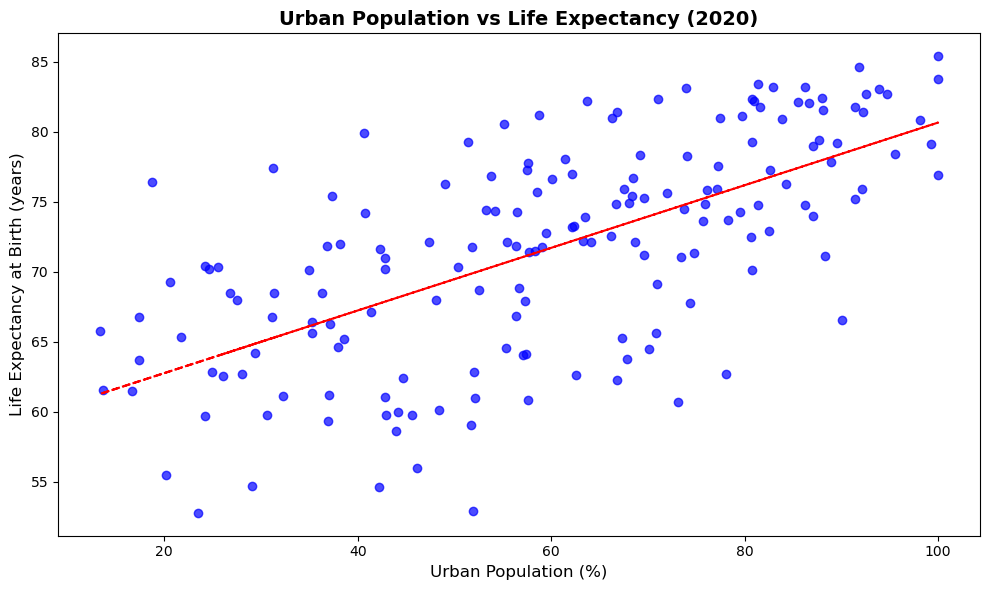

In [11]:
# Urban Population vs Life Expectancy (2020)

#Dataframe information
df_urban_life = df[['year', 'country', 'wdi_urban_population_pct', 'wdi_life_expectancy_at_birth']].dropna()
df_urban_life_year = df_urban_life[df_urban_life['year'] == 2020]

# Create graph
plt.figure(figsize=(10, 6))
plt.scatter(df_urban_life_year['wdi_urban_population_pct'], 
            df_urban_life_year['wdi_life_expectancy_at_birth'], 
            color='blue', alpha=0.7)

# Titles and labels
plt.title('Urban Population vs Life Expectancy (2020)', fontsize=14, fontweight='bold')
plt.xlabel('Urban Population (%)', fontsize=12)
plt.ylabel('Life Expectancy at Birth (years)', fontsize=12)

# Tendency line
m, b = np.polyfit(df_urban_life_year['wdi_urban_population_pct'], df_urban_life_year['wdi_life_expectancy_at_birth'], 1)
plt.plot(df_urban_life_year['wdi_urban_population_pct'], m * df_urban_life_year['wdi_urban_population_pct'] + b, color='red', linestyle='--')

# Show graph
plt.tight_layout()
plt.show()